# METAR comparison to reanalysis products 

## Overview
This notebook explores how we might compare METAR products to gridded reanalysis data sets, like ERA-5, WRF, or **AORC**. We compare single a single site in a time series and look at the comparison in some interactive map-based visualizations. 

For this example, we compare METAR with [AORC](https://registry.opendata.aws/noaa-nws-aorc/) data, a high-resolution reanalysis product produced by NOAA for the continental U.S. and Alaska from 1979-2023. This dataset has only 8 meteorological variables so is relatively simple to understand. 

1. Accessing METAR data
2. Accessing AORC data
3. Comparing time series 
4. Interactive map-based visualizations

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Pandas](https://pandas.pydata.org/) | Necessary | Familiarity with tabular data |
| ? | Necessary |  |
| [S3 file access](https://github.com/s3fs-fuse/s3fs-fuse) | Helpful | Understanding data access from a cloud-hosted bucket |

- **Time to learn**: 25 minutes 

---

## Imports 

In [54]:
# basic data wrangling  
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr

# data access  
import duckdb
import s3fs

# utilities 
from datetime import datetime, timedelta
# import metpy.calc as mpcalc
# from metpy.units import units
import scipy.signal as signal

# visualization packages 
import matplotlib.pyplot as plt
from seaborn import set_theme
set_theme()
from lonboard import viz, Map, ScatterplotLayer, HeatmapLayer
from lonboard.view_state import MapViewState
from lonboard.basemap import MaplibreBasemap, CartoStyle

## Time series comparison 

### Get METAR data 
Data is hosted on [Dynamical](https://dynamical.org/). Choose a location and a time range. 

Our METAR Parquet file contains some weird column names, so we define some more descriptive names here. The full documentation for column names can be found [here](https://unidata.github.io/gempak/man/parm/apxA.html). 

In [3]:
col_refs = {
    'tmpc': ['Temperature', '°C'], 
    'relh': ['Relative Humidity', '%'],
    'drct': ['Wind Direction', 'degrees from North'],
    'sknt': ['Wind Speed', 'knots'],
}

In [4]:
def valid_date(date): 
    '''
    Helper function to check that the date range is valid for METAR and AORC.
    '''
    assert isinstance(date, datetime)
    assert date >= datetime(1979, 1, 1, 0), 'Date cannot be earlier than 1979' 
    assert date < datetime(2024, 1, 1, 0), 'Date cannot be more recent than 2023' 
    return date

In [5]:
# define target! 
target = (39.8328, -104.6575)
target_code = 'DEN'
target = (39.6426, -106.9177)
target_code = 'EGE'
# TODO add "find_closest_metar" functionality, bounding box search, etc. 

time_start = valid_date(datetime(2021, 1, 1, 0))
time_end = valid_date(datetime(2021, 5, 31, 23))

target_vars = ['tmpc', 'relh', 'drct', 'sknt']

We'll start by looking at one airport in the Colorado Rocky Mountains. The Eagle-Vail airport is located just off i70 to the West of Denver. 

In [59]:
gdf = gpd.GeoDataFrame(
    {"station": [target_code]},
    geometry=gpd.points_from_xy([target[1]], [target[0]]),
    crs="EPSG:4326"
)
layer = ScatterplotLayer.from_geopandas(gdf, get_radius=7, radius_units="pixels", get_fill_color=[255, 0, 0, 200])
co_view = MapViewState(longitude=-105.7189, latitude=39.0598, zoom=6.5)
labeled_basemap = MaplibreBasemap(style=CartoStyle.Voyager)

# Render the interactive map
Map(layers=[layer], 
    view_state=co_view,
    basemap=labeled_basemap)

We'll need different files if the time range spans multiple years. 

In [6]:
metar_base = "https://data.source.coop/dynamical/asos-parquet"
metar_urls = [f"{metar_base}/year={y}/data.parquet" for y in range(time_start.year, time_end.year + 1)]
metar_urls

['https://data.source.coop/dynamical/asos-parquet/year=2021/data.parquet']

In [7]:
df = duckdb.execute(f"""
    SELECT valid, longitude, latitude, station, name, country, {', '.join(target_vars)}
    FROM read_parquet($1, hive_partitioning=true)
    WHERE station = $2 and 
          valid between $3 and $4
    ORDER BY valid
""", [metar_urls, target_code, time_start, time_end]).fetchdf()

In [29]:
df = duckdb.execute(f"""
    SELECT *
    FROM read_parquet($1, hive_partitioning=true)
    WHERE station = $2
    ORDER BY valid
""", [metar_urls, target_code]).fetchdf()

In [30]:
df.columns

Index(['station', 'valid', 'longitude', 'latitude', 'tmpf', 'tmpc', 'dwpf',
       'dwpc', 'relh', 'drct', 'sknt', 'gust', 'alti', 'mslp', 'vsby', 'p01i',
       'p01m', 'state', 'name', 'elevation', 'country', 'county', 'wfo',
       'tzname', 'geometry', 'bbox', 'year'],
      dtype='object')

In [10]:
gdf_metar = gpd.GeoDataFrame(
                df, 
                geometry=gpd.points_from_xy(df.longitude,
                                            df.latitude)
)
gdf_metar

,valid,longitude,latitude,station,name,country,tmpc,relh,drct,sknt,geometry
0,2021-01-01 00:56:00+00:00,-106.9177,39.6426,EGE,EAGLE CO. REGIONAL,US,-6.11,73.94,0.0,0.0,POINT (-106.9177 39.6426)
1,2021-01-01 01:56:00+00:00,-106.9177,39.6426,EGE,EAGLE CO. REGIONAL,US,-6.72,77.48,0.0,0.0,POINT (-106.9177 39.6426)
2,2021-01-01 02:56:00+00:00,-106.9177,39.6426,EGE,EAGLE CO. REGIONAL,US,-6.72,81.30,0.0,0.0,POINT (-106.9177 39.6426)
3,2021-01-01 03:56:00+00:00,-106.9177,39.6426,EGE,EAGLE CO. REGIONAL,US,-6.72,81.30,0.0,0.0,POINT (-106.9177 39.6426)
4,2021-01-01 04:56:00+00:00,-106.9177,39.6426,EGE,EAGLE CO. REGIONAL,US,-7.22,84.49,270.0,3.0,POINT (-106.9177 39.6426)
...,...,...,...,...,...,...,...,...,...,...,...
4140,2021-05-31 19:56:00+00:00,-106.9177,39.6426,EGE,EAGLE CO. REGIONAL,US,22.22,21.82,310.0,7.0,POINT (-106.9177 39.6426)
4141,2021-05-31 20:56:00+00:00,-106.9177,39.6426,EGE,EAGLE CO. REGIONAL,US,20.00,28.34,270.0,19.0,POINT (-106.9177 39.6426)
4142,2021-05-31 21:42:00+00:00,-106.9177,39.6426,EGE,EAGLE CO. REGIONAL,US,18.00,25.60,260.0,10.0,POINT (-106.9177 39.6426)
4143,2021-05-31 21:56:00+00:00,-106.9177,39.6426,EGE,EAGLE CO. REGIONAL,US,18.89,22.86,240.0,5.0,POINT (-106.9177 39.6426)


### Get the AORC data for the target time and location. 

AORC data has 8 variables: 
1. **APCP_surface:** 
Accumulated precipitation at surface (mm) 
2. **TMP_2maboveground:**
Temperature at 2m above ground (K)
3. **SPFH_2maboveground:**
Specific humidity at 2m above ground (g/g)
4. **DLWRF_surface:**
Downward longwave radiation (W/m^2)
5. **DSWRF_surface:**
Downward shortwave radiation (W/m^2)
6. **PRES_surface:** 
Pressure at surface (Pa)
7. **UGRD_10maboveground:**
East-West wind speed (m/s) 
8. **VGRD_10maboveground:**
North-South wind speed (m/s)

In order to compare this to the METAR data, we'll need to do some conversions. The function `aorc_to_metar_cols` does this below. 

- Temperature K --> Temperature C
- Specific humidity --> Relative humidity
- U/V wind speeds (m/s) --> Wind direction (deg) and wind speed (knots) 


In [11]:
def aorc_to_metar_cols(df_aorc): 
    '''
    '''
    for col in target_vars: 
        if col == 'tmpc' : 
            print('Converting TMP_2maboveground in K to tmpc in C') 
            # df_aorc.rename('TMP_2maboveground', 'tmpc') 
            df_aorc['tmpc'] = df_aorc['TMP_2maboveground'] - 273
        if col == 'relh' : 
            print('Converting SPFH_2maboveground to relh (%)') 
            q = df_aorc['SPFH_2maboveground']
            tmp = df_aorc['tmpc']
            prs = df_aorc['PRES_surface']
            df_aorc['relh'] = spech_to_relh(q, tmp, prs)
        if col == 'drct' : 
            print('Converting UGRD_10maboveground and VGRD_10maboveground to wind direction (deg)') 
            dir_rad = np.arctan2(df_aorc['UGRD_10maboveground'], df_aorc['VGRD_10maboveground'])
            dir_deg = np.degrees(dir_rad) + 180.0
            
            # Ensure all angles fall strictly between 0 and 360 degrees (e.g., handles negative angles smoothly)
            df_aorc['drct'] = np.mod(dir_deg, 360.0)  
        if col == 'sknt' : 
            print('Converting UGRD_10maboveground and VGRD_10maboveground to wind speed (knots)') 
            speed_mps = np.hypot(df_aorc['UGRD_10maboveground'], df_aorc['VGRD_10maboveground'])
            df_aorc['sknt'] = speed_mps * 1.94384
            
            
            # df_aorc['relh'] = (tmp.dims, rh_vals)
        
    return df_aorc

def spech_to_relh(q, tmp, prs): 
    p_hpa = prs / 100.0

    # 3. Step-by-step vectorized calculation
    # Calculate mixing ratio (w)
    w = q / (1.0 - q)
    
    # Calculate saturation vapor pressure (es) in hPa via Bolton (1980)
    es = 6.112 * np.exp((17.67 * tmp) / (tmp + 243.5))
    
    # Calculate saturation mixing ratio (ws)
    epsilon = 0.62198
    ws = epsilon * es / (p_hpa - es)
    
    # Calculate Relative Humidity (%) bounded logically between 0% and 100%
    rh_array = (w / ws) * 100.0
    rh_array = np.clip(rh_array, 0.0, 100.0)
    return rh_array

AORC data is hosted in Zarr format by NOAA on a public S3 bucket. 

In [12]:
aorc_base = "noaa-nws-aorc-v1-1-1km" 
aorc_urls = [f"s3://{aorc_base}/{y}.zarr" for y in range(time_start.year, time_end.year + 1)]
aorc_urls

['s3://noaa-nws-aorc-v1-1-1km/2021.zarr']

In [13]:
s3_out = s3fs.S3FileSystem(anon=True)
fileset_aorc = [
    s3fs.S3Map(root=url, s3=s3_out, check=False)
    for url in aorc_urls
]

df_aorc = xr.open_mfdataset(fileset_aorc, engine='zarr')

In [14]:
# select the target point and target time range 
df_aorc_pt = df_aorc.sel(
    latitude=target[0], 
    longitude=target[1],
    method="nearest"
)
df_aorc_pt = df_aorc_pt.sel(
    time=slice(time_start, time_end)
)
del df_aorc # clean up

In [15]:
df_aorc_pt = aorc_to_metar_cols(df_aorc_pt)
df_aorc_pt = df_aorc_pt[target_vars]

Converting TMP_2maboveground in K to tmpc in C
Converting SPFH_2maboveground to relh (%)
Converting UGRD_10maboveground and VGRD_10maboveground to wind direction (deg)
Converting UGRD_10maboveground and VGRD_10maboveground to wind speed (knots)


In [16]:
gdf_aorc = df_aorc_pt.to_dataframe().reset_index()
gdf_aorc['time'] = pd.to_datetime(gdf_aorc['time']).dt.tz_localize('UTC').astype('datetime64[us, UTC]')
gdf_aorc = gpd.GeoDataFrame(
    gdf_aorc, 
    geometry=gpd.points_from_xy(gdf_aorc.longitude,
                                gdf_aorc.latitude),
    crs="EPSG:4326" # Standard WGS84 lat/lon coordinate system
)

In [17]:
gdf_aorc

,time,tmpc,relh,drct,sknt,latitude,longitude,geometry
0,2021-01-01 00:00:00+00:00,-6.799996,76.547479,161.565051,1.229392,39.640881,-106.91759,POINT (-106.91759 39.64088)
1,2021-01-01 01:00:00+00:00,-6.099996,75.896046,270.000000,0.194384,39.640881,-106.91759,POINT (-106.91759 39.64088)
2,2021-01-01 02:00:00+00:00,-6.799996,76.624564,206.565051,0.434656,39.640881,-106.91759,POINT (-106.91759 39.64088)
3,2021-01-01 03:00:00+00:00,-6.899996,80.807339,180.000000,0.000000,39.640881,-106.91759,POINT (-106.91759 39.64088)
4,2021-01-01 04:00:00+00:00,-6.499996,78.333940,0.000000,1.360688,39.640881,-106.91759,POINT (-106.91759 39.64088)
...,...,...,...,...,...,...,...,...
3619,2021-05-31 19:00:00+00:00,20.300004,35.507184,244.230672,6.259648,39.640881,-106.91759,POINT (-106.91759 39.64088)
3620,2021-05-31 20:00:00+00:00,21.700004,25.150933,250.016893,6.825619,39.640881,-106.91759,POINT (-106.91759 39.64088)
3621,2021-05-31 21:00:00+00:00,19.600004,27.636826,279.462322,17.735876,39.640881,-106.91759,POINT (-106.91759 39.64088)
3622,2021-05-31 22:00:00+00:00,18.000004,26.340362,241.699244,5.740091,39.640881,-106.91759,POINT (-106.91759 39.64088)


### Compare! 
Now that everything is matched up and in the same format, we can make some plots to compare the two datasets. 

Here, we just plot each variable against the other. 

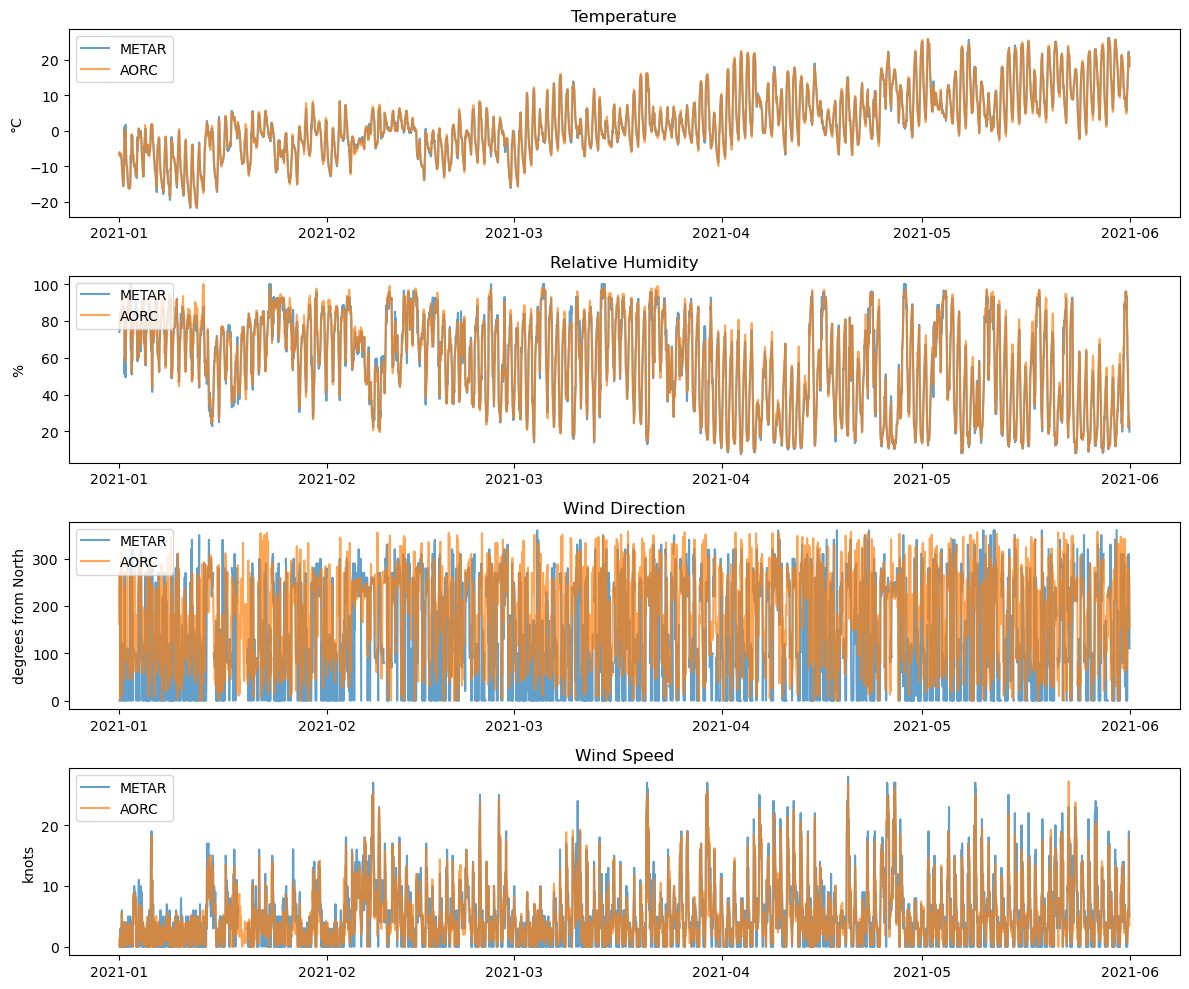

In [18]:
fig, axes = plt.subplots(len(target_vars), 1, figsize=(3 * len(target_vars), 10)) 

for i, v in enumerate(target_vars): 
    axes[i].set_title(col_refs[v][0])
    axes[i].set_ylabel(col_refs[v][1])
    axes[i].plot(gdf_metar['valid'], gdf_metar[v], label='METAR', alpha=0.7) 
    axes[i].plot(gdf_aorc['time'], gdf_aorc[v], label='AORC', alpha=0.7)

    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()

That's a little messy. Let's try plotting with a median filter. 

A kernel size of 25 for the median filter means that the window size will be about 1 day. 

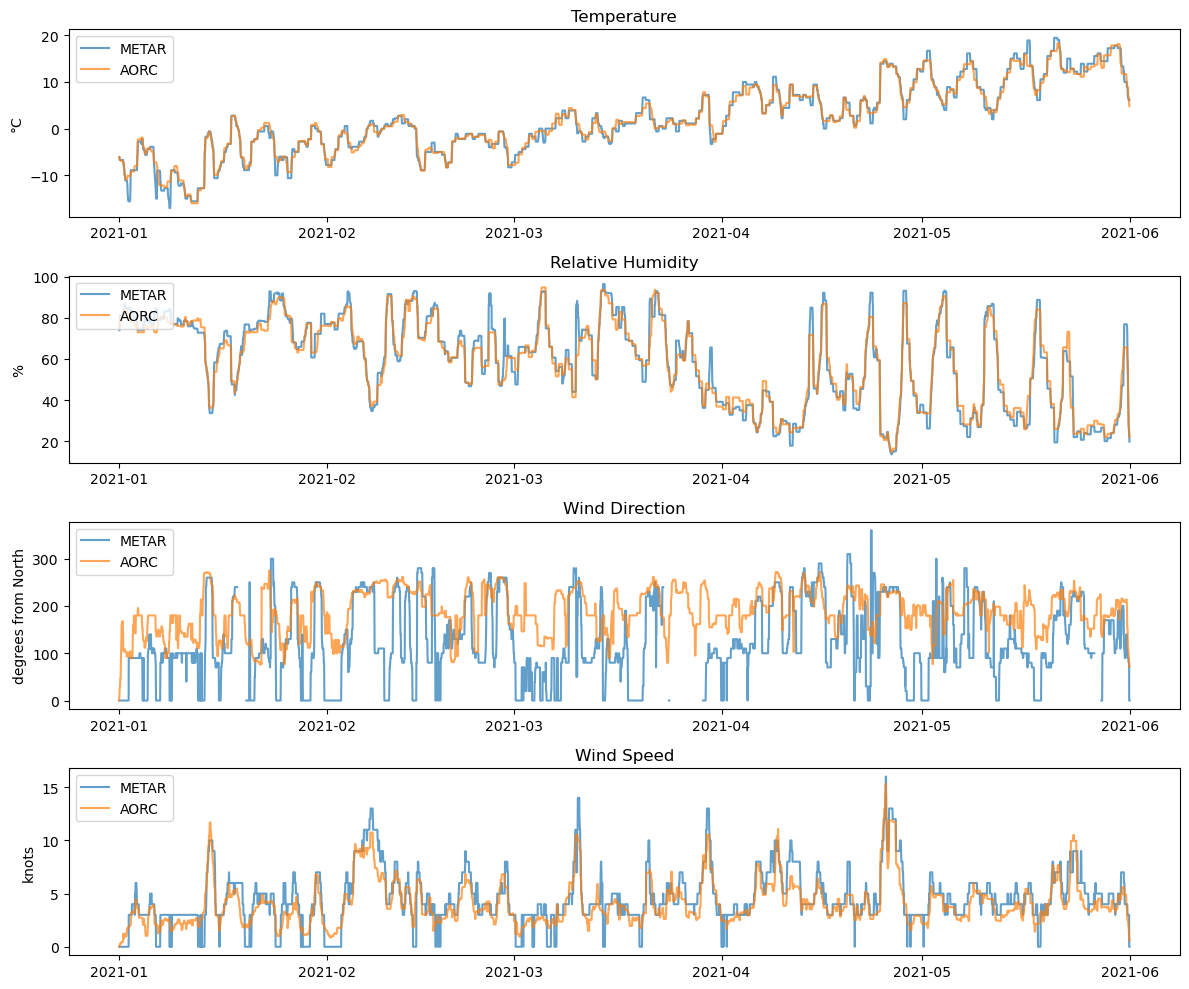

In [19]:
fig, axes = plt.subplots(len(target_vars), 1, figsize=(3 * len(target_vars), 10)) 

for i, v in enumerate(target_vars): 
    axes[i].set_title(col_refs[v][0])
    axes[i].set_ylabel(col_refs[v][1])
    axes[i].plot(gdf_metar['valid'], signal.medfilt(gdf_metar[v], kernel_size=25), label='METAR', alpha=0.7) 
    axes[i].plot(gdf_aorc['time'], signal.medfilt(gdf_aorc[v], kernel_size=25), label='AORC', alpha=0.7)

    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()

Now, lets plot just the different between each the values. This is the METAR minus the AORC, so this difference is positive where the AORC is underestimating the METAR data and negative where it is overestimating. 

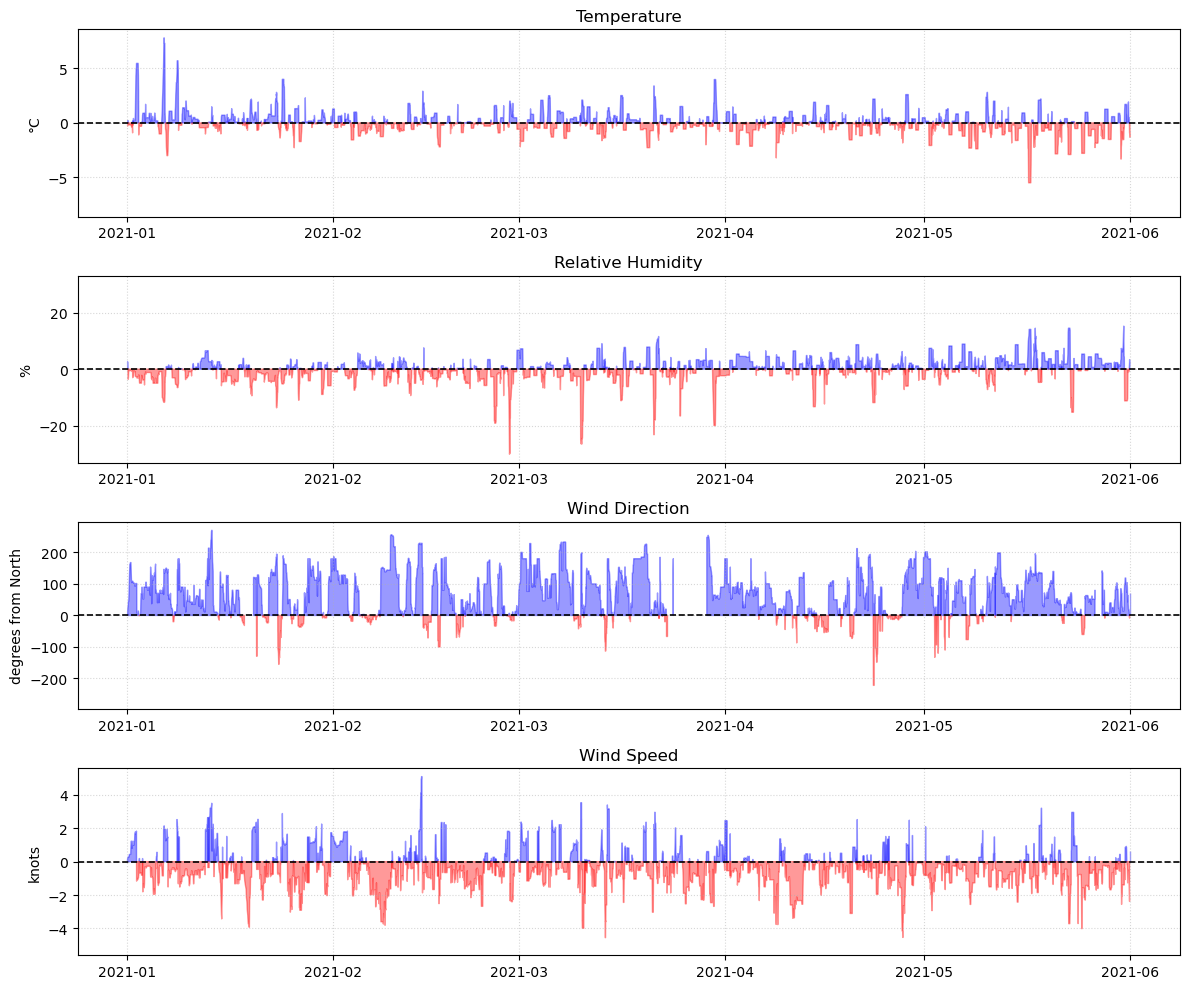

In [22]:
fig, axes = plt.subplots(len(target_vars), 1, figsize=(3 * len(target_vars), 10)) 

for i, v in enumerate(target_vars):
    metar_series = pd.Series(
        # gdf_metar[v],
        signal.medfilt(gdf_metar[v], kernel_size=25), 
        index=gdf_metar['valid']
    )
    aorc_series = pd.Series(
        # gdf_aorc[v],
        signal.medfilt(gdf_aorc[v], kernel_size=25), 
        index=gdf_aorc['time']
    )
    
    aorc_aligned = aorc_series.reindex(metar_series.index, method='nearest')
    
    diff = aorc_aligned - metar_series
    x_dates = diff.index.values
    y_values = diff.values

    # axes[i].plot(x_dates, y_values, color='black', linewidth=1, alpha=0., label='METAR - AORC')
    axes[i].axhline(0, color='black', linewidth=1.2, linestyle='--') # Baseline 0

    # axes[i].plot(x_dates, y_values.where(y_values > 0), 
    #              color='red', alpha=0.4, interpolate=True)
    # axes[i].plot(x_dates, y_values.where(y_values < 0), 
    #              color='blue', alpha=0.4, interpolate=True)
    axes[i].fill_between(x_dates, 0, y_values, where=(y_values > 0), 
                         color='blue', alpha=0.4, interpolate=True)
    axes[i].fill_between(x_dates, 0, y_values, where=(y_values < 0), 
                         color='red', alpha=0.4, interpolate=True)

    max_val = np.nanmax(np.abs(y_values))
    if max_val > 0:
        axes[i].set_ylim(-max_val * 1.1, max_val * 1.1) # Add 10% padding for visual neatness

    axes[i].set_title(col_refs[v][0])
    axes[i].set_ylabel(col_refs[v][1])
    axes[i].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

These plots show us that the AORC underestimates wind speed and is off on the wind direction by about 180 degrees, at the Eagle-Vail airport. 